#  Tesla Deliveries — End-to-End ML Pipeline
**Dataset:** Tesla EA Deliveries and Production Data (2015–2025)  
**Tasks:** EDA · Preprocessing · Feature Engineering · Regression · Hyperparameter Tuning · Time Series Forecasting

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

#### Load Data

In [32]:
df = pd.read_csv('tesla_deliveries_production.csv')
print('Shape:', df.shape)
df.head()

Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [33]:
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

Missing values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


#### Exploratory Data Analysis

In [34]:
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
Year,2640.000000,2020.000000,3.162877,2015.000000,2017.000000,2020.000000,2023.000000,2025.000000
Month,2640.000000,6.500000,3.452707,1.000000,3.750000,6.500000,9.250000,12.000000
Estimated_Deliveries,2640.000000,9922.199621,3935.950093,48.000000,7292.000000,9857.000000,12510.250000,25704.000000
Production_Units,2640.000000,10655.847348,4260.600858,50.000000,7828.250000,10546.500000,13469.000000,28939.000000
Avg_Price_USD,2640.000000,84907.340330,20123.258036,50003.700000,67726.365000,85058.510000,102373.042500,119965.360000
Battery_Capacity_kWh,2640.000000,87.059470,20.836265,60.000000,75.000000,82.000000,100.000000,120.000000
Range_km,2640.000000,500.257576,120.868549,330.000000,418.000000,470.000000,586.250000,719.000000
CO2_Saved_tons,2640.000000,744.076989,353.221224,3.070000,499.620000,699.515000,943.765000,2548.550000
Charging_Stations,2640.000000,8932.133712,3469.565883,3002.000000,5897.750000,8901.500000,11938.000000,14996.000000


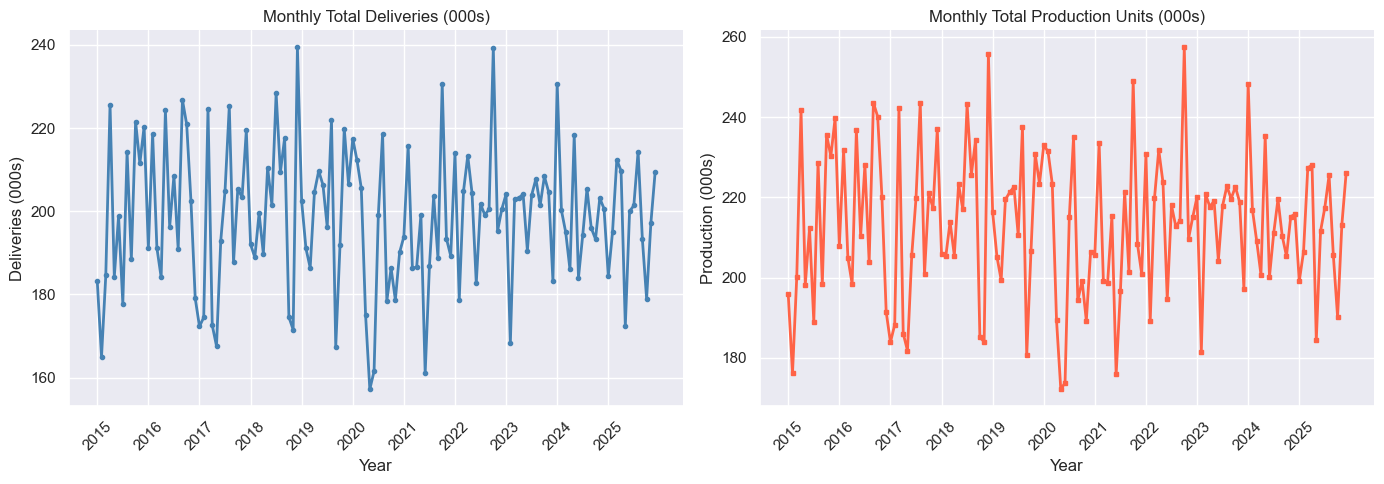

In [35]:
mo = df.groupby(['Year','Month'])[['Estimated_Deliveries','Production_Units']].sum().reset_index()
mo['t'] = mo['Year'] + (mo['Month'] - 1) / 12

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mo['t'], mo['Estimated_Deliveries'] / 1000,
             marker='o', color='steelblue', lw=2, ms=3)
axes[0].set_title('Monthly Total Deliveries (000s)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Deliveries (000s)')
axes[0].set_xticks(range(2015, 2026))
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(mo['t'], mo['Production_Units'] / 1000,
             marker='s', color='tomato', lw=2, ms=3)
axes[1].set_title('Monthly Total Production Units (000s)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Production (000s)')
axes[1].set_xticks(range(2015, 2026))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

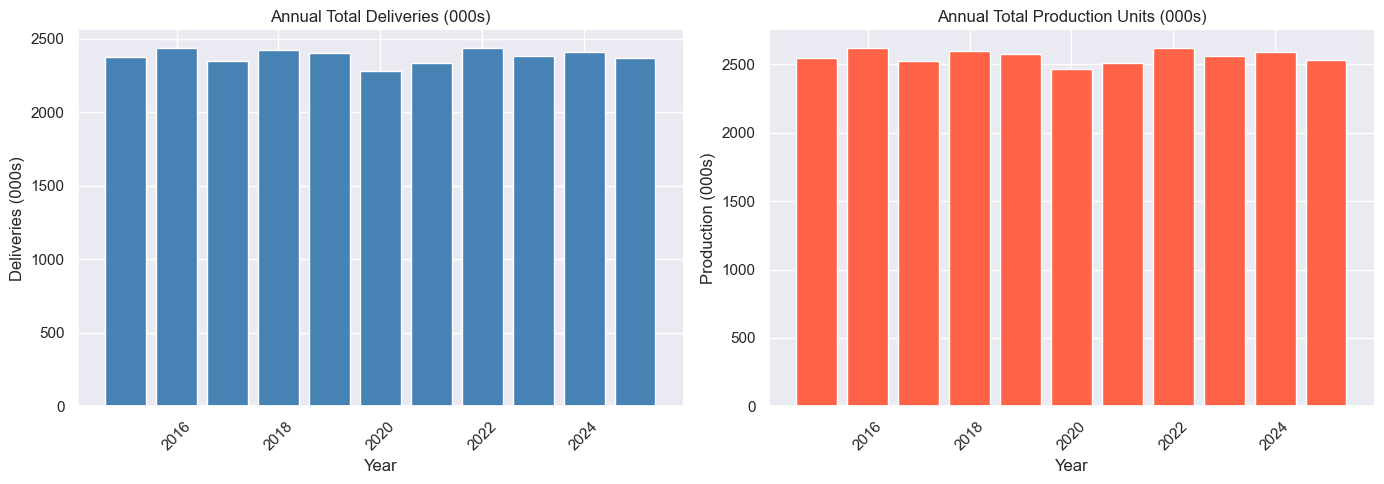

In [36]:
yr = df.groupby('Year')[['Estimated_Deliveries','Production_Units']].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(yr.index, yr['Estimated_Deliveries'] / 1000,
            color='steelblue', edgecolor='white')
axes[0].set_title('Annual Total Deliveries (000s)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Deliveries (000s)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(yr.index, yr['Production_Units'] / 1000,
            color='tomato', edgecolor='white')
axes[1].set_title('Annual Total Production Units (000s)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Production (000s)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

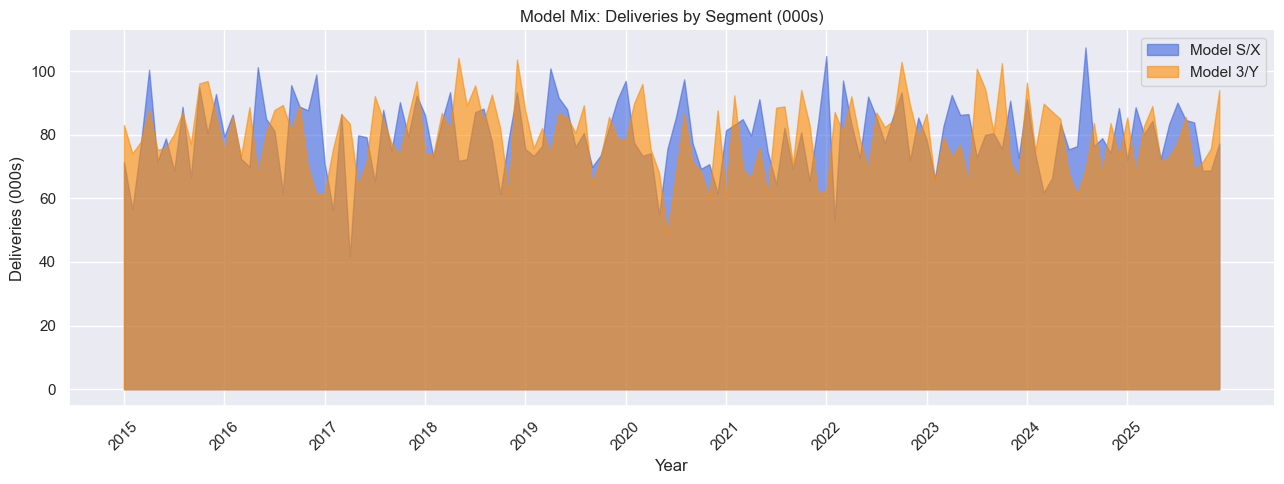

In [37]:
sx  = df[df['Model'].isin(['Model S','Model X'])].groupby(['Year','Month'])['Estimated_Deliveries'].sum().reset_index()
m3y = df[df['Model'].isin(['Model 3','Model Y'])].groupby(['Year','Month'])['Estimated_Deliveries'].sum().reset_index()

sx['t']  = sx['Year']  + (sx['Month']  - 1) / 12
m3y['t'] = m3y['Year'] + (m3y['Month'] - 1) / 12

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(sx['t'],  sx['Estimated_Deliveries']  / 1000,
                alpha=0.6, label='Model S/X', color='royalblue')
ax.fill_between(m3y['t'], m3y['Estimated_Deliveries'] / 1000,
                alpha=0.6, label='Model 3/Y', color='darkorange')
ax.set_title('Model Mix: Deliveries by Segment (000s)')
ax.set_xlabel('Year')
ax.set_ylabel('Deliveries (000s)')
ax.set_xticks(range(2015, 2026))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

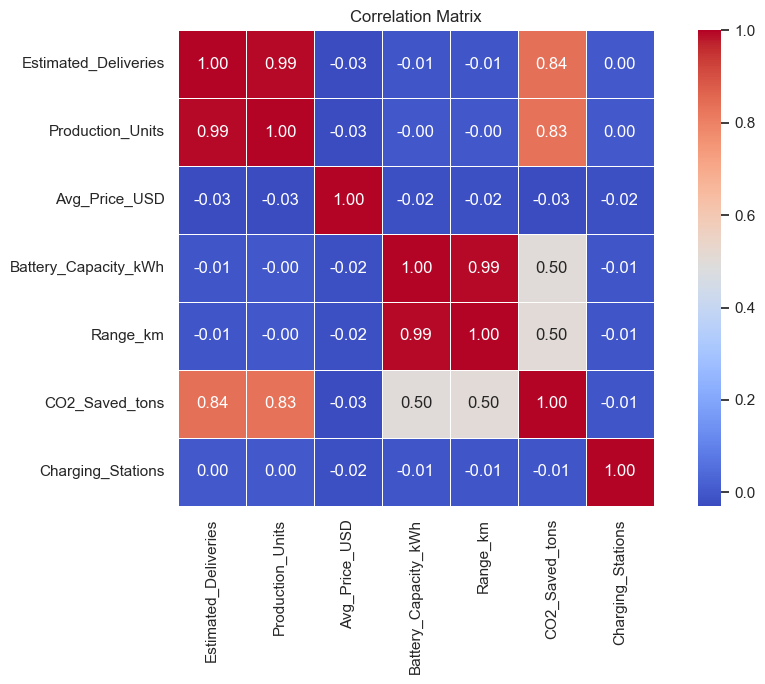

In [38]:
num_cols = ['Estimated_Deliveries','Production_Units','Avg_Price_USD',
            'Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

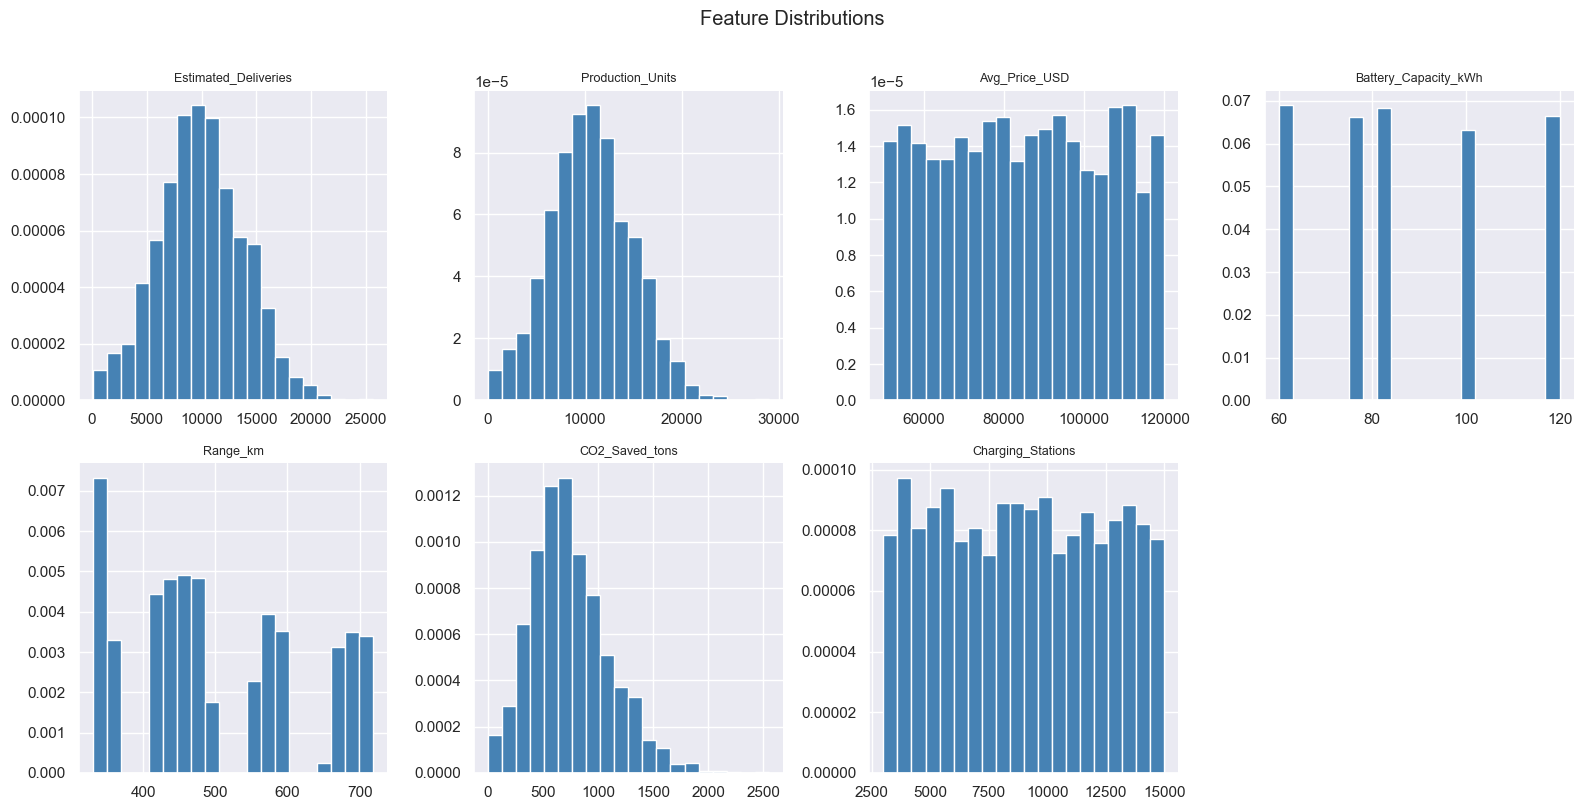

In [39]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white', density=True)
    axes[i].set_title(col, fontsize=9)
axes[-1].set_visible(False)
plt.suptitle('Feature Distributions', y=1.01)
plt.tight_layout()
plt.show()

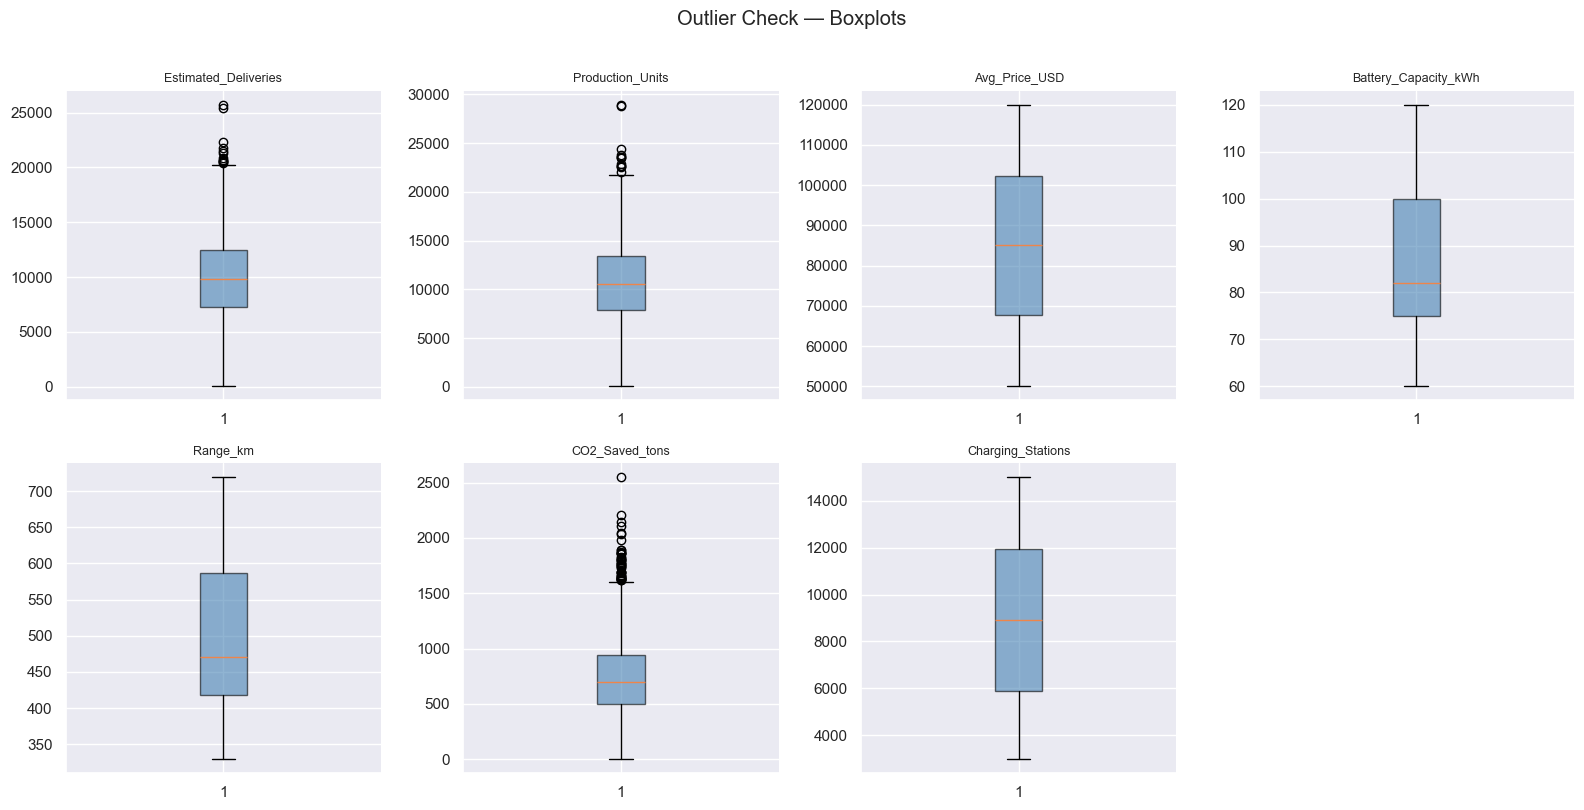

In [40]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=9)
axes[-1].set_visible(False)
plt.suptitle('Outlier Check — Boxplots', y=1.01)
plt.tight_layout()
plt.show()

#### Preprocessing

In [41]:
print('Missing values:', df.isnull().sum().sum())

le_model  = LabelEncoder()
le_region = LabelEncoder()
le_src    = LabelEncoder()

df['Model_enc']  = le_model.fit_transform(df['Model'])
df['Region_enc'] = le_region.fit_transform(df['Region'])
df['Src_enc']    = le_src.fit_transform(df['Source_Type'])

print('Model  :', dict(zip(le_model.classes_,  le_model.transform(le_model.classes_))))
print('Region :', dict(zip(le_region.classes_, le_region.transform(le_region.classes_))))
print('Src    :', dict(zip(le_src.classes_,    le_src.transform(le_src.classes_))))

Missing values: 0
Model  : {'Cybertruck': 0, 'Model 3': 1, 'Model S': 2, 'Model X': 3, 'Model Y': 4}
Region : {'Asia': 0, 'Europe': 1, 'Middle East': 2, 'North America': 3}
Src    : {'Estimated (Region)': 0, 'Interpolated (Month)': 1, 'Official (Quarter)': 2}


In [42]:
from scipy import stats

z        = np.abs(stats.zscore(df[num_cols]))
df_clean = df[(z < 3).all(axis=1)].reset_index(drop=True)
print(f'Rows before: {len(df)}  |  After outlier removal: {len(df_clean)}')

Rows before: 2640  |  After outlier removal: 2616


#### Feature Engineering

In [43]:
df_fe = df_clean.copy()

df_fe['prod_util']       = df_fe['Estimated_Deliveries'] / (df_fe['Production_Units'] + 1)
df_fe['price_per_km']    = df_fe['Avg_Price_USD'] / (df_fe['Range_km'] + 1)
df_fe['co2_per_del']     = df_fe['CO2_Saved_tons'] / (df_fe['Estimated_Deliveries'] + 1)
df_fe['station_per_del'] = df_fe['Charging_Stations'] / (df_fe['Estimated_Deliveries'] + 1)
df_fe['time_idx']        = df_fe['Year'] + (df_fe['Month'] - 1) / 12
df_fe['quarter']         = ((df_fe['Month'] - 1) // 3) + 1
df_fe['q_sin']           = np.sin(2 * np.pi * df_fe['quarter'] / 4)
df_fe['q_cos']           = np.cos(2 * np.pi * df_fe['quarter'] / 4)
df_fe['m_sin']           = np.sin(2 * np.pi * df_fe['Month'] / 12)
df_fe['m_cos']           = np.cos(2 * np.pi * df_fe['Month'] / 12)

print(f'Features shape: {df_fe.shape}')
df_fe.head()

Features shape: (2616, 25)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,...,prod_util,price_per_km,co2_per_del,station_per_del,time_idx,quarter,q_sin,q_cos,m_sin,m_cos
0,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,...,0.911645,141.698519,0.065682,2.011585,2015.083333,1,1.000000e+00,6.123234e-17,8.660254e-01,0.500000
1,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,...,0.915234,245.087983,0.071991,1.672729,2019.000000,1,1.000000e+00,6.123234e-17,5.000000e-01,0.866025
2,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,...,0.896472,125.238303,0.106783,1.423581,2021.083333,1,1.000000e+00,6.123234e-17,8.660254e-01,0.500000
3,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,...,0.914020,173.484562,0.099142,0.704808,2016.916667,4,-2.449294e-16,1.000000e+00,-2.449294e-16,1.000000
4,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,...,0.923077,181.863117,0.071535,1.245008,2020.250000,2,1.224647e-16,-1.000000e+00,8.660254e-01,-0.500000


#### Regression Modeling
**Target:** `Estimated_Deliveries`

In [44]:
target    = 'Estimated_Deliveries'
drop_cols = [target, 'Model', 'Region', 'Source_Type']

X = df_fe.drop(columns=drop_cols)
y = df_fe[target]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

sc     = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s = sc.transform(X_te)

print(f'Train: {X_tr.shape}  |  Test: {X_te.shape}')

Train: (2092, 21)  |  Test: (524, 21)


In [45]:
def eval_model(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    p    = model.predict(Xte)
    mae  = mean_absolute_error(yte, p)
    rmse = np.sqrt(mean_squared_error(yte, p))
    r2   = r2_score(yte, p)
    cv   = cross_val_score(model, Xtr, ytr, cv=5, scoring='r2').mean()
    return {'Model': name, 'MAE': round(mae,1), 'RMSE': round(rmse,1),
            'R²': round(r2,4), 'CV R²': round(cv,4)}

models = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=1.0),
    'Lasso'             : Lasso(alpha=1.0),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = [eval_model(n, m, X_tr_s, y_tr, X_te_s, y_te) for n, m in models.items()]
res_df  = pd.DataFrame(results).set_index('Model').sort_values('R²', ascending=False)
res_df.style.background_gradient(cmap='Greens', subset=['R²', 'CV R²'])

,MAE,RMSE,R²,CV R²
Model,,,,
Gradient Boosting,68.500000,93.800000,0.999400,0.999400
Random Forest,63.700000,99.500000,0.999300,0.999100
Linear Regression,105.000000,152.400000,0.998400,0.998400
Ridge,105.300000,153.600000,0.998400,0.998400
Lasso,105.100000,153.200000,0.998400,0.998400


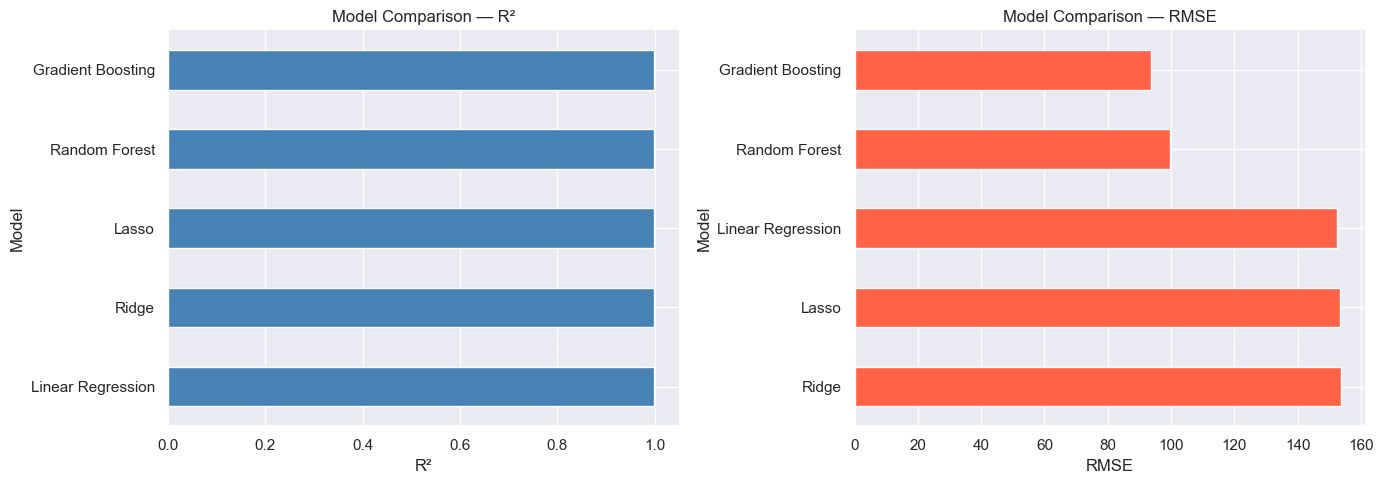

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

res_df['R²'].sort_values().plot(kind='barh', ax=axes[0],
                                color='steelblue', edgecolor='white')
axes[0].set_title('Model Comparison — R²')
axes[0].set_xlabel('R²')

res_df['RMSE'].sort_values(ascending=False).plot(kind='barh', ax=axes[1],
                                                  color='tomato', edgecolor='white')
axes[1].set_title('Model Comparison — RMSE')
axes[1].set_xlabel('RMSE')

plt.tight_layout()
plt.show()

#### Hyperparameter Tuning — Random Forest

In [47]:
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 5, 10],
    'min_samples_split': [2, 5],
}

gs = GridSearchCV(RandomForestRegressor(random_state=42),
                  param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=0)
gs.fit(X_tr_s, y_tr)

print('Best params:', gs.best_params_)
print(f'Best CV R²: {gs.best_score_:.4f}')

Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Best CV R²: 0.9991


MAE  : 66.5
RMSE : 100.7
R²   : 0.9993


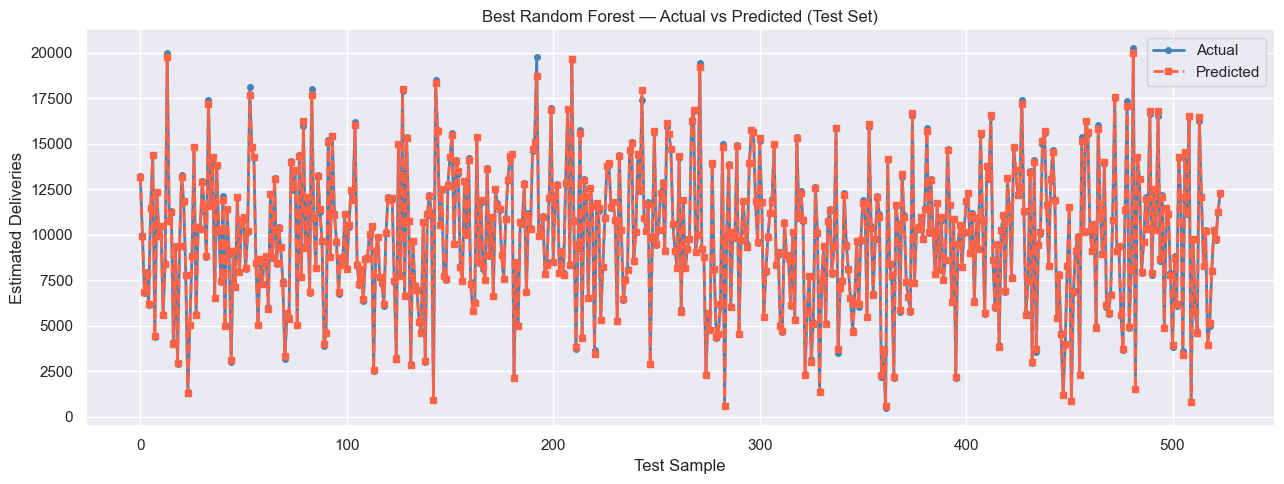

In [48]:
best_rf = gs.best_estimator_
p_best  = best_rf.predict(X_te_s)

print(f'MAE  : {mean_absolute_error(y_te, p_best):.1f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_te, p_best)):.1f}')
print(f'R²   : {r2_score(y_te, p_best):.4f}')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_te.values,  label='Actual',    color='steelblue', lw=2, marker='o', ms=4)
ax.plot(p_best,       label='Predicted', color='tomato',    lw=2, ls='--', marker='s', ms=4)
ax.set_title('Best Random Forest — Actual vs Predicted (Test Set)')
ax.set_xlabel('Test Sample')
ax.set_ylabel('Estimated Deliveries')
ax.legend()
plt.tight_layout()
plt.show()

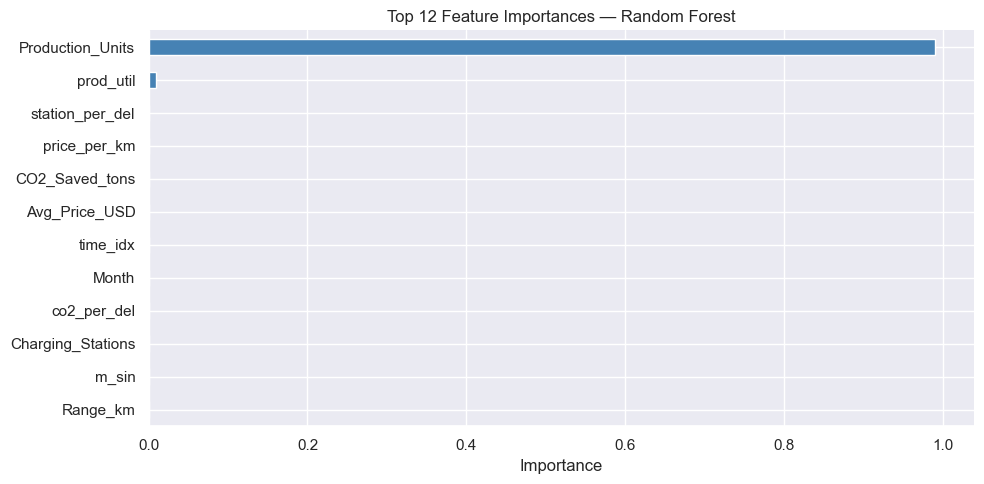

In [49]:
feat_imp = pd.Series(best_rf.feature_importances_,
                     index=X_tr.columns).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 12 Feature Importances — Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

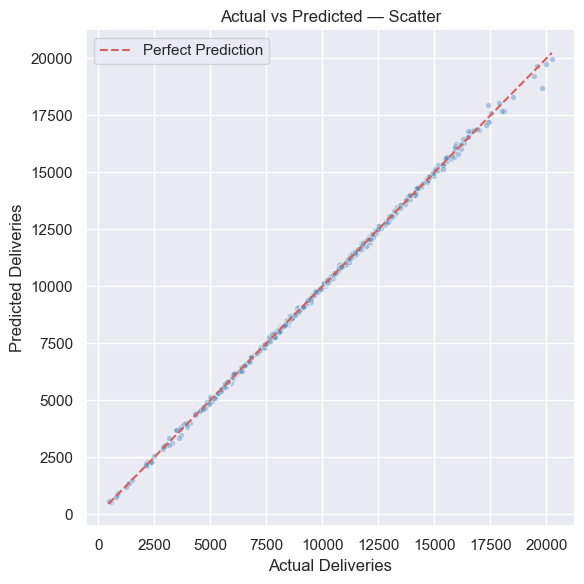

In [50]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_te, p_best, alpha=0.4, color='steelblue', edgecolors='white', s=20)
lims = [min(y_te.min(), p_best.min()), max(y_te.max(), p_best.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Deliveries')
ax.set_ylabel('Predicted Deliveries')
ax.set_title('Actual vs Predicted — Scatter')
ax.legend()
plt.tight_layout()
plt.show()

#### Time Series Forecasting

In [51]:
!pip install statsmodels -q

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


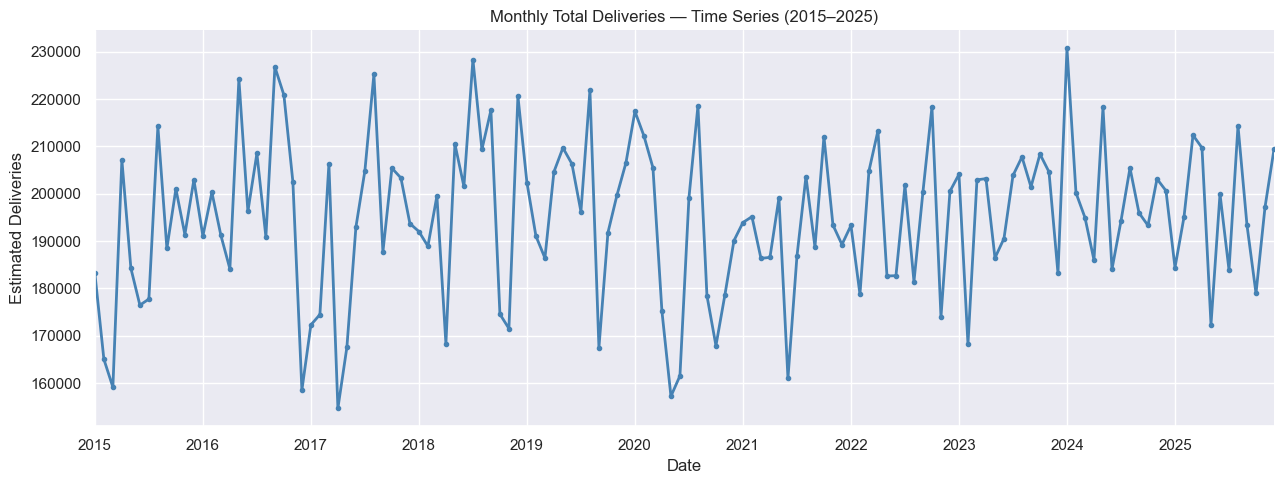

In [52]:
mo_agg = (df_clean.groupby(['Year','Month'])['Estimated_Deliveries']
           .sum()
           .reset_index()
           .sort_values(['Year','Month']))

mo_agg['date'] = pd.to_datetime(mo_agg[['Year','Month']].assign(day=1))
ts = mo_agg.set_index('date')['Estimated_Deliveries']

fig, ax = plt.subplots(figsize=(13, 5))
ts.plot(ax=ax, color='steelblue', marker='o', ms=3, lw=2)
ax.set_title('Monthly Total Deliveries — Time Series (2015–2025)')
ax.set_ylabel('Estimated Deliveries')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

In [53]:
adf = adfuller(ts)
print(f'ADF Statistic : {adf[0]:.4f}')
print(f'p-value       : {adf[1]:.4f}')
print(f'Stationary?   : {adf[1] < 0.05}')

ADF Statistic : -10.1729
p-value       : 0.0000
Stationary?   : True


After 1st diff — p-value: 0.0000  |  Stationary? True


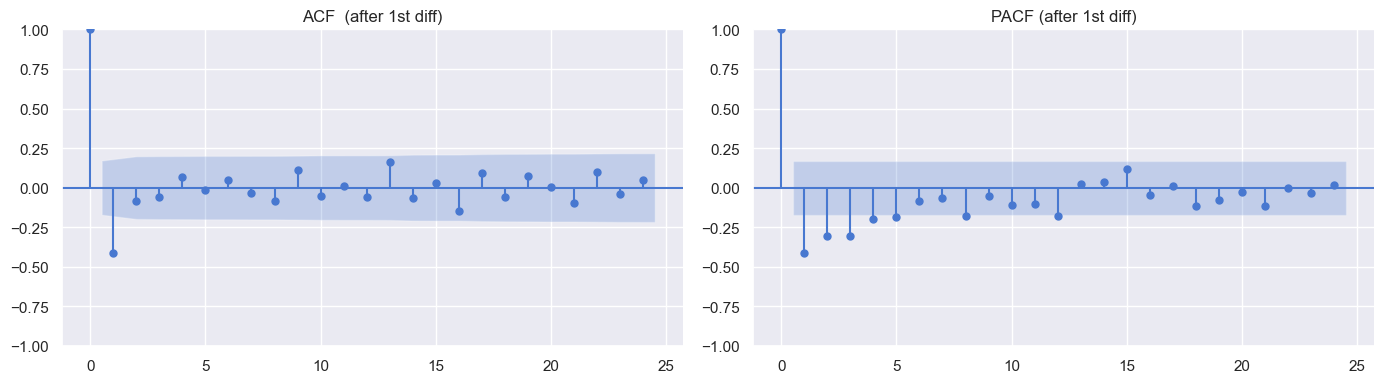

In [54]:
ts_diff = ts.diff().dropna()

adf2 = adfuller(ts_diff)
print(f'After 1st diff — p-value: {adf2[1]:.4f}  |  Stationary? {adf2[1] < 0.05}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_diff,  lags=24, ax=axes[0], title='ACF  (after 1st diff)')
plot_pacf(ts_diff, lags=24, ax=axes[1], title='PACF (after 1st diff)')
plt.tight_layout()
plt.show()

In [55]:
n_test    = 12
tr_ts, te_ts = ts.iloc[:-n_test], ts.iloc[-n_test:]

sarima = SARIMAX(tr_ts,
                 order=(1, 1, 1),
                 seasonal_order=(1, 1, 1, 12),
                 enforce_stationarity=False,
                 enforce_invertibility=False)

res = sarima.fit(disp=False)
print(res.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0132      0.187      0.071      0.944      -0.353       0.379
ma.L1         -0.6804      0.098     -6.961      0.000      -0.872      -0.489
ar.S.L12      -0.0629      0.225     -0.280      0.779      -0.503       0.377
ma.S.L12      -0.4714      0.171     -2.749      0.006      -0.808      -0.135
sigma2      6.127e+08   1.47e-10   4.17e+18      0.000    6.13e+08    6.13e+08


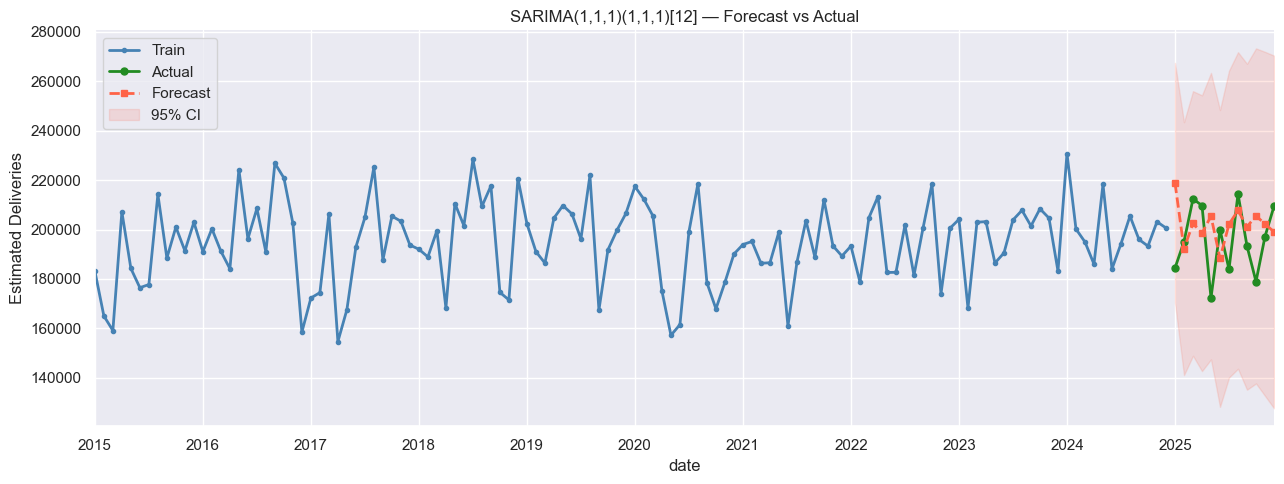

SARIMA — MAE: 14814.8  |  RMSE: 18075.3


In [56]:
fc   = res.get_forecast(steps=n_test)
fc_m = fc.predicted_mean
ci   = fc.conf_int()

fig, ax = plt.subplots(figsize=(13, 5))
tr_ts.plot(ax=ax, label='Train',    color='steelblue',   lw=2, marker='o', ms=3)
te_ts.plot(ax=ax, label='Actual',   color='forestgreen', lw=2, marker='o', ms=5)
fc_m.plot(ax=ax,  label='Forecast', color='tomato',      lw=2, ls='--', marker='s', ms=5)
ax.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1],
                color='tomato', alpha=0.15, label='95% CI')
ax.set_title('SARIMA(1,1,1)(1,1,1)[12] — Forecast vs Actual')
ax.set_ylabel('Estimated Deliveries')
ax.legend()
plt.tight_layout()
plt.show()

mae_s  = mean_absolute_error(te_ts, fc_m)
rmse_s = np.sqrt(mean_squared_error(te_ts, fc_m))
print(f'SARIMA — MAE: {mae_s:.1f}  |  RMSE: {rmse_s:.1f}')

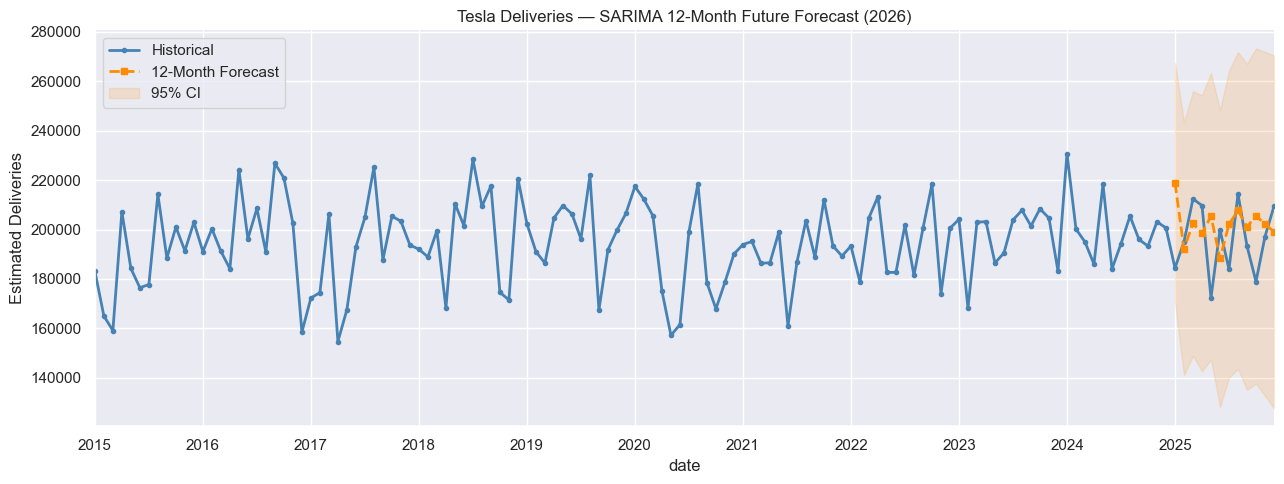

In [57]:
future_fc = res.get_forecast(steps=12)
future_m  = future_fc.predicted_mean
future_ci = future_fc.conf_int()

fig, ax = plt.subplots(figsize=(13, 5))
ts.plot(ax=ax, label='Historical', color='steelblue', lw=2, marker='o', ms=3)
future_m.plot(ax=ax, label='12-Month Forecast', color='darkorange', lw=2, ls='--', marker='s', ms=5)
ax.fill_between(future_ci.index,
                future_ci.iloc[:,0], future_ci.iloc[:,1],
                color='darkorange', alpha=0.15, label='95% CI')
ax.set_title('Tesla Deliveries — SARIMA 12-Month Future Forecast (2026)')
ax.set_ylabel('Estimated Deliveries')
ax.legend()
plt.tight_layout()
plt.show()

#### Results Summary

In [58]:
summary = pd.DataFrame({
    'Stage' : ['Best Regression Model', 'SARIMA Forecast'],
    'Model' : ['Random Forest (tuned)', 'SARIMA(1,1,1)(1,1,1)[12]'],
    'MAE'   : [round(mean_absolute_error(y_te, p_best),1), round(mae_s,1)],
    'RMSE'  : [round(np.sqrt(mean_squared_error(y_te, p_best)),1), round(rmse_s,1)],
    'R²'    : [round(r2_score(y_te, p_best),4), '-'],
})
summary

,Stage,Model,MAE,RMSE,R²
0,Best Regression Model,Random Forest (tuned),66.5,100.7,0.9993
1,SARIMA Forecast,"SARIMA(1,1,1)(1,1,1)[12]",14814.8,18075.3,-
